Loaded marts as_of=2025-12-13T16-28-39Z
2025-08-31 23:00:00+00:00 2025-09-01 00:00:00+00:00
RMSE: 28.16
MAE:  19.40
Naive RMSE: 43.66
hour_sin            -8.173392
dow_sin             -1.896222
hour                -0.109775
gen_renewable_mw    -0.003522
gen_fossil_mw       -0.000245
wind_ramp_1h        -0.000123
res_ramp_1h         -0.000083
solar_ramp_1h        0.000040
load_ramp_1h         0.001228
load_forecast_mw     0.004072
load_error_mw        0.004346
gen_res_share        0.469987
dow                  0.534030
dow_cos              1.573320
hour_cos            10.892810
dtype: float64
R²: 0.701
count    2465.000000
mean       -4.509288
std        27.806409
min       -63.546532
25%       -20.387569
50%        -6.392964
75%         7.836456
max       257.600329
Name: Day-ahead Price (EUR/MWh), dtype: float64
Residual Model RMSE: 27.06
Residual Model MAE:  18.53
Residual Model R²:   0.052
Final Model RMSE: 27.06
Final Model MAE:  18.53
Final R²: 0.724


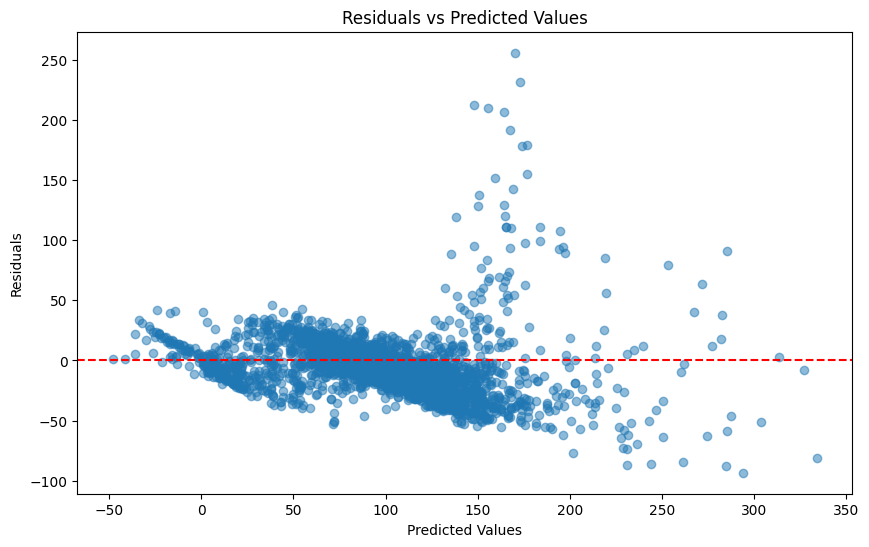

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ----------------------------------------------------------------------
# Baseline Regression Model
# ----------------------------------------------------------------------

# ---------- LOCAL DEBUG DEFAULT ----------
as_of_str = "2025-12-13T16-28-39Z"

fp = Path(f"../../data/03_marts/as_of={as_of_str}/Joined.csv")
df = pd.read_csv(fp)

print(f"Loaded marts as_of={as_of_str}")


RENEWABLE = [
    "Solar", "Wind Onshore", "Wind Offshore",
    "Hydro Run-of-river and pondage",
    "Other renewable",
    "Geothermal"
]

FOSSIL = [
    "Fossil Gas", "Fossil Hard coal", "Fossil Brown coal/Lignite",
    "Fossil Oil", "Fossil Coal-derived gas"
]

# optional (je nachdem wie du’s nutzen willst)
HYDRO = ["Hydro Water Reservoir", "Hydro Pumped Storage",
         "Hydro Run-of-river and pondage"]
OTHER = ["Biomass", "Waste", "Other"]

df["gen_renewable_mw"] = df[RENEWABLE].sum(axis=1)
df["gen_fossil_mw"] = df[FOSSIL].sum(axis=1)
df["gen_total_mw"] = df[[*RENEWABLE, *FOSSIL, *HYDRO, *OTHER]].sum(axis=1)
df["gen_res_share"] = df["gen_renewable_mw"] / df["gen_total_mw"] * 100.0


df["wind_total"] = df["Wind Onshore"] + df["Wind Offshore"]

df["wind_ramp_1h"] = df["wind_total"] - df["wind_total"].shift(1)
df["solar_ramp_1h"] = df["Solar"] - df["Solar"].shift(1)

df["res_ramp_1h"] = (
    df["wind_ramp_1h"] + df["solar_ramp_1h"]
)

df["load_ramp_1h"] = (
    df["Actual Total Load (MW)"] - df["Actual Total Load (MW)"].shift(1)
)

DROP_COLS = RENEWABLE + FOSSIL + HYDRO + OTHER
df = df.drop(columns=DROP_COLS, errors="ignore")


df["load_forecast_mw"] = df["Day-ahead Total Load Forecast (MW)"]
df["load_actual_mw"] = df["Actual Total Load (MW)"]

df["load_error_mw"] = df["load_actual_mw"] - \
    df["load_forecast_mw"]


df["start_time"] = pd.to_datetime(
    df["start_time"],
    utc=True,
    errors="coerce"
)
df["hour"] = df["start_time"].dt.hour
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow"] = df["start_time"].dt.weekday
df["dow_sin"] = np.sin(2 * np.pi * df["dow"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dow"] / 7)


FEATURES = [
    "load_forecast_mw",
    "load_error_mw",
    "gen_renewable_mw",
    "gen_fossil_mw",
    "gen_res_share",
    "hour",
    "hour_sin",
    "hour_cos",
    "dow",
    "dow_sin",
    "dow_cos",
    "wind_ramp_1h",
    "solar_ramp_1h",
    "res_ramp_1h",
    "load_ramp_1h"
]

TARGET = "Day-ahead Price (EUR/MWh)"

df_model = df.sort_values("start_time").reset_index(drop=True)

split_ts = pd.Timestamp("2025-09-01T00:00:00Z")

train = df_model[df_model["start_time"] < split_ts]
test = df_model[df_model["start_time"] >= split_ts]


# nach dem Split:
train = train.dropna(subset=FEATURES + [TARGET])
test = test.dropna(subset=FEATURES + [TARGET])

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

assert "Day-ahead Price (EUR/MWh)" not in FEATURES
assert not any("price" in f.lower() for f in FEATURES)
print(train["start_time"].max(), test["start_time"].min())


model = LinearRegression()
model.fit(X_train, y_train)

y_pred_base = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae = mean_absolute_error(y_test, y_pred_base)

print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")


df = df.sort_values("start_time")

y_naive = df.loc[test.index, "Day-ahead Price (EUR/MWh)"].shift(24)

mask = y_naive.notna() & y_test.notna()
rmse_naive = np.sqrt(mean_squared_error(y_test[mask], y_naive[mask]))
print(f"Naive RMSE: {rmse_naive:.2f}")

coef = pd.Series(
    model.coef_,
    index=FEATURES
).sort_values()

print(coef)

r2 = r2_score(y_test, y_pred_base)
print(f"R²: {r2:.3f}")

resid = y_test - y_pred_base
print(resid.describe())

# ----------------------------------------------------------------------
# Residual Modeling
# ----------------------------------------------------------------------

FEATURES_RESIDUAL = [
    "load_forecast_mw",
    "load_error_mw",
    "gen_renewable_mw",
    "gen_fossil_mw",
    "gen_res_share",
    "hour",
    "hour_sin",
    "hour_cos",
    "dow",
    "dow_sin",
    "dow_cos",
    "wind_ramp_1h",
    "solar_ramp_1h",
    "res_ramp_1h",
    "load_ramp_1h",
    # Worsen the R^2 by including weather features
    # "temp",
    # "wspd",
    # "tsun"
]

# create residual target for train and test set
test["y_pred_base"] = model.predict(X_test)
test["residual"] = test[TARGET] - test["y_pred_base"]
train["y_pred_base"] = model.predict(X_train)
train["residual"] = train[TARGET] - train["y_pred_base"]

TARGET_RESIDUAL = "residual"

X_train = train[FEATURES_RESIDUAL]
y_train = train[TARGET_RESIDUAL]
X_test = test[FEATURES_RESIDUAL]
y_test = test[TARGET_RESIDUAL]


res_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

res_model.fit(X_train, y_train)
y_pred_resid = res_model.predict(X_test)
rmse_res = np.sqrt(mean_squared_error(y_test, y_pred_resid))
mae_res = mean_absolute_error(y_test, y_pred_resid)
print(f"Residual Model RMSE: {rmse_res:.2f}")
print(f"Residual Model MAE:  {mae_res:.2f}")
print(f"Residual Model R²:   {r2_score(y_test, y_pred_resid):.3f}")

# ----------------------------------------------------------------------
# Final Evaluation
# ----------------------------------------------------------------------

y_final_pred = test["y_pred_base"] + y_pred_resid
rmse_final = np.sqrt(mean_squared_error(
    test[TARGET], y_final_pred))
mae_final = mean_absolute_error(
    test[TARGET], y_final_pred)
print(f"Final Model RMSE: {rmse_final:.2f}")
print(f"Final Model MAE:  {mae_final:.2f}")

y_pred_final = y_pred_base + y_pred_resid
# final R²
r2_final = r2_score(test[TARGET], y_pred_final)
print(f"Final R²: {r2_final:.3f}")

# Residuals vs Predicted plot
resid = test[TARGET] - y_pred_final

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_final, resid, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")
plt.show()


In [3]:
y_final_pred.describe()

count    2465.000000
mean       97.778373
std        50.406320
min       -48.138186
25%        68.714440
50%        99.402338
75%       128.670755
max       334.027974
Name: y_pred_base, dtype: float64

In [4]:
test[TARGET].describe()

count    2465.000000
mean       92.140266
std        51.533242
min       -46.753750
25%        73.551250
50%        91.187500
75%       109.528750
max       426.291250
Name: Day-ahead Price (EUR/MWh), dtype: float64

In [5]:
test

,start_time,Day-ahead Price (EUR/MWh),ingested_at_price,Actual Total Load (MW),Day-ahead Total Load Forecast (MW),ingested_at_load,ingested_at,temp,dwpt,rhum,...,load_actual_mw,load_error_mw,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos,y_pred_base,residual
5833,2025-09-01 00:00:00+00:00,83.26875,2025-12-13 09:18:43+00:00,38319.5050,38104.8575,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,14.1,12.3,89.0,...,38319.5050,214.6475,0,0.000000,1.000000e+00,0,0.000000,1.000000,70.684347,12.584403
5834,2025-09-01 01:00:00+00:00,81.74375,2025-12-13 09:18:43+00:00,38021.2875,38252.1275,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,13.6,12.3,92.0,...,38021.2875,-230.8400,1,0.258819,9.659258e-01,0,0.000000,1.000000,69.816771,11.926979
5835,2025-09-01 02:00:00+00:00,82.73625,2025-12-13 09:18:43+00:00,38707.6675,39393.5500,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,13.4,12.5,94.0,...,38707.6675,-685.8825,2,0.500000,8.660254e-01,0,0.000000,1.000000,71.367240,11.369010
5836,2025-09-01 03:00:00+00:00,93.17875,2025-12-13 09:18:43+00:00,42282.4400,43028.8850,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,13.2,12.6,96.0,...,42282.4400,-746.4450,3,0.707107,7.071068e-01,0,0.000000,1.000000,84.587673,8.591077
5837,2025-09-01 04:00:00+00:00,115.53875,2025-12-13 09:18:43+00:00,50102.4225,50113.9825,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,12.9,12.4,97.0,...,50102.4225,-11.5600,4,0.866025,5.000000e-01,0,0.000000,1.000000,113.944385,1.594365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8296,2025-12-12 15:00:00+00:00,152.14375,2025-12-13 09:18:43+00:00,66136.0325,65993.6800,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,NaN,NaN,NaN,...,66136.0325,142.3525,15,-0.707107,-7.071068e-01,4,-0.433884,-0.900969,187.076271,-34.932521
8297,2025-12-12 16:00:00+00:00,150.19000,2025-12-13 09:18:43+00:00,67961.0625,67687.9925,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,NaN,NaN,NaN,...,67961.0625,273.0700,16,-0.866025,-5.000000e-01,4,-0.433884,-0.900969,195.261613,-45.071613
8298,2025-12-12 17:00:00+00:00,137.66750,2025-12-13 09:18:43+00:00,66952.5900,67797.4450,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,NaN,NaN,NaN,...,66952.5900,-844.8550,17,-0.965926,-2.588190e-01,4,-0.433884,-0.900969,189.921196,-52.253696
8299,2025-12-12 18:00:00+00:00,129.72875,2025-12-13 09:18:43+00:00,65365.6275,65759.0900,2025-12-13 09:34:08+00:00,2025-12-13 16:28:39.181603+00:00,NaN,NaN,NaN,...,65365.6275,-393.4625,18,-1.000000,-1.836970e-16,4,-0.433884,-0.900969,186.795721,-57.066971


In [6]:
import numpy as np
import pandas as pd

# Inputs (as in your notebook)
# y_final_pred: pd.Series (or np.array) of predictions
# test: pd.DataFrame that contains TARGET column
# TARGET: str

y_pred = pd.Series(np.asarray(y_final_pred), index=test.index, name="y_hat")
y_true = test[TARGET].rename("y_true")

df = pd.concat([y_true, y_pred], axis=1)

# Core diagnostics columns
df["e"] = df["y_true"] - df["y_hat"]
df["abs_e"] = df["e"].abs()
df["sq_e"] = df["e"] ** 2

# choose your loss (start with abs error)
df["L"] = df["abs_e"]          # or df["sq_e"]

# Convenience: also keep predicted/true levels for later slicing
df["y_hat_bin"] = pd.qcut(df["y_hat"], q=10, duplicates="drop")  # optional, for quick plots
df.head()


,y_true,y_hat,e,abs_e,sq_e,L,y_hat_bin
5833,83.26875,75.699486,7.569264,7.569264,57.293754,7.569264,"(75.168, 87.577]"
5834,81.74375,75.004532,6.739218,6.739218,45.417054,6.739218,"(59.958, 75.168]"
5835,82.73625,76.459839,6.276411,6.276411,39.393337,6.276411,"(75.168, 87.577]"
5836,93.17875,88.738735,4.440015,4.440015,19.713733,4.440015,"(87.577, 99.402]"
5837,115.53875,117.838935,-2.300185,2.300185,5.290850,2.300185,"(110.344, 122.737]"


In [7]:
# Example Z choices
df["Z_yhat"] = df["y_hat"]                 # Z = ŷ
df["Z_load"] = test["load_forecast_mw"]    # Z = einzelnes Feature (falls vorhanden)
df["Z_hour"] = test["hour"]
df["Z_hour_sin"] = test["hour_sin"]
df["Z_hour_cos"] = test["hour_cos"]

In [26]:
# Deine konstruierten Z-Features
df["Z_yhat"] = df["y_hat"]
df["Z_load"] = test["load_forecast_mw"]      # oder wie die Spalte exakt heißt
df["Z_hour"] = test["hour"]
df["Z_hour_sin"] = test["hour_sin"]
df["Z_hour_cos"] = test["hour_cos"]
df["Z_dow"] = test["dow"]
df["Z_dow_sin"] = test["dow_sin"]
df["Z_dow_cos"] = test["dow_cos"]


In [27]:
feature_cols = [
    "Z_yhat",
    "Z_load",
    "Z_hour",
    "Z_hour_sin",
    "Z_hour_cos",
    "Z_dow",
    "Z_dow_sin",
    "Z_dow_cos",
]


In [8]:
alpha = 0.90
q = df["L"].quantile(alpha)
df["S"] = (df["L"] >= q).astype(int)
coverage = df["S"].mean()
loss_share = df.loc[df["S"]==1, "L"].sum() / df["L"].sum()

In [9]:
print(
    f"Coverage: {coverage:.3f} ({coverage*100:.1f}%) | "
    f"Loss share: {loss_share:.3f} ({loss_share*100:.1f}%)"
)

Coverage: 0.100 (10.0%) | Loss share: 0.317 (31.7%)


In [10]:
import numpy as np
from scipy.stats import entropy
from sklearn.feature_selection import mutual_info_classif

results = []

#alphas = [0.6, 0.7, 0.8, 0.85, 0.9, 0.95]
alphas = [x/100 for x in range(0, 100, 1)]


for alpha in alphas:
    threshold = np.quantile(df["L"], 1-alpha)
    S = (df["L"] >= threshold).astype(int)
    p = np.array([S.mean(), 1 - S.mean()])
    H = entropy(p, base=np.e)

    for name, Z in {
        "y_hat": df[["y_hat"]],
        "Z_hour": df[["Z_hour"]]
    }.items():
        I = mutual_info_classif(Z, S, discrete_features=False)[0]
        score = I / H

        results.append({
            "alpha": alpha,
            "Z": name,
            "MI": I,
            "H": H,
            "score": score
        })


# Crazy Tree based MI discovery for feature interaction

In [36]:
df["L"].mean()


np.float64(18.528248986034523)

In [37]:
import numpy as np

# z.B. 0.03 soll heißen: 3% Failures
alpha = alpha_star
L = df["L"].to_numpy()

# 0.97-Quantil
threshold = np.quantile(L, 1 - alpha)
S = (L >= threshold).astype(int)

print("alpha:", alpha)
print("threshold:", threshold)
print("failure_rate:", S.mean())


alpha: 0.03
threshold: 54.21783668734497
failure_rate: 0.03002028397565923


In [38]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

best_threshold = threshold

# S from your best alpha (or sweep to pick global best)
S = (df["L"] >= best_threshold).astype(int)

# CART: learns splits like "Z_hour > 14 AND y_hat > quantile → high failure"
tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=20)  # Tune for sparsity
tree.fit(df[feature_cols], S)  # All Z's at once

# Per-leaf NMI (your metric!)
leaf_nmics = []
for leaf_id in range(tree.tree_.n_leaves):  # Actually extract via apply
    in_leaf = tree.apply(df[feature_cols]) == leaf_id
    if in_leaf.sum() > 10:  # Min size
        leaf_S = S[in_leaf]
        p_leaf = [leaf_S.mean(), 1 - leaf_S.mean()]
        H_leaf = entropy(p_leaf)
        # Approx I via conditional purity (or mutual_info_classif if scalar proxy)
        purity_lift = leaf_S.mean() / S.mean()  # Simple proxy; use sklearn.mi for exact
        leaf_nmi = np.log(purity_lift) / H_leaf if H_leaf > 0 else 0
        leaf_nmics.append({'leaf': leaf_id, 'nmi': leaf_nmi, 'purity': leaf_S.mean(), 'size': in_leaf.mean()})


In [39]:
import pandas as pd

imp = pd.Series(tree.feature_importances_, index=feature_cols)
imp = imp.sort_values(ascending=False)
print(imp)


Z_yhat        0.815865
Z_load        0.125064
Z_dow         0.059071
Z_hour        0.000000
Z_hour_sin    0.000000
Z_hour_cos    0.000000
Z_dow_sin     0.000000
Z_dow_cos     0.000000
dtype: float64


In [40]:
from sklearn.tree import export_text

rules = export_text(tree, feature_names=feature_cols)
print(rules)


|--- Z_yhat <= 163.89
|   |--- Z_yhat <= 147.97
|   |   |--- Z_yhat <= 132.11
|   |   |   |--- class: 0
|   |   |--- Z_yhat >  132.11
|   |   |   |--- class: 0
|   |--- Z_yhat >  147.97
|   |   |--- Z_load <= 62348.77
|   |   |   |--- class: 0
|   |   |--- Z_load >  62348.77
|   |   |   |--- class: 0
|--- Z_yhat >  163.89
|   |--- Z_load <= 64679.93
|   |   |--- Z_dow <= 1.50
|   |   |   |--- class: 1
|   |   |--- Z_dow >  1.50
|   |   |   |--- class: 0
|   |--- Z_load >  64679.93
|   |   |--- Z_yhat <= 218.88
|   |   |   |--- class: 0
|   |   |--- Z_yhat >  218.88
|   |   |   |--- class: 0



In [41]:
import numpy as np

leaf_ids = tree.apply(df[feature_cols])
out = []

for leaf in np.unique(leaf_ids):
    mask = leaf_ids == leaf
    if mask.sum() < 20:
        continue
    leaf_S = S[mask]
    out.append({
        "leaf": leaf,
        "size": mask.mean(),                # Anteil am Datensatz
        "failure_rate": leaf_S.mean(),      # P(S=1 | Leaf)
        "lift": leaf_S.mean() / S.mean()     # wie viel schlimmer als global
    })

leaf_df = pd.DataFrame(out).sort_values("lift", ascending=False)
leaf_df


,leaf,size,failure_rate,lift
4,10,0.008519,0.714286,23.793436
7,14,0.017039,0.500000,16.655405
5,11,0.013387,0.363636,12.113022
2,6,0.028398,0.185714,6.186293
6,13,0.030426,0.106667,3.553153
3,7,0.033671,0.024096,0.802670
1,4,0.091278,0.013333,0.444144
0,3,0.777282,0.000000,0.000000


<Axes: title={'center': 'Failure Lift per Leaf'}, xlabel='leaf'>

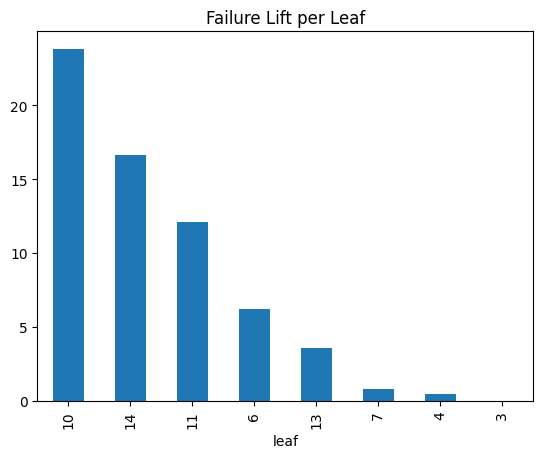

In [42]:
leaf_df.plot(
    x="leaf", y="lift", kind="bar", legend=False,
    title="Failure Lift per Leaf"
)


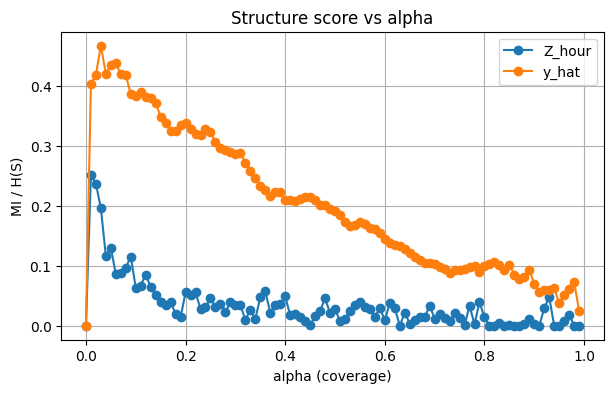

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# results -> DataFrame
res = pd.DataFrame(results)

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

for z, g in res.groupby("Z"):
    g = g.sort_values("alpha")
    ax.plot(g["alpha"], g["score"], marker="o", label=z)

ax.set_xlabel("alpha (coverage)")
ax.set_ylabel("MI / H(S)")
ax.set_title("Structure score vs alpha")
ax.legend()
ax.grid(True)

plt.show()


In [ ]:
res

In [12]:
import pandas as pd

res = pd.DataFrame(results)

alpha_star = (
    res[res["Z"] == "y_hat"]
    .sort_values("score", ascending=False)
    .iloc[0]["alpha"]
)

print(f"Best alpha: {alpha_star:.3f}")


Best alpha: 0.030


/var/folders/76/fw3vf7lx5jx_p5d21p8rzd280000gn/T/ipykernel_51056/3728784542.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("yhat_bin")


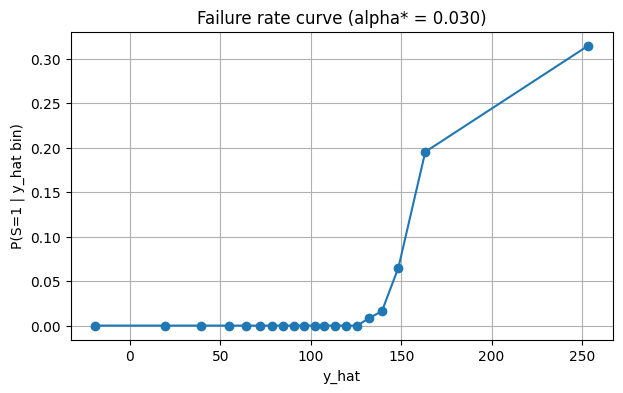

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# build S(alpha*)
thr = df["L"].quantile(1 - alpha_star)

df_ = df[["y_hat", "L"]].dropna().copy()
df_["S"] = (df_["L"] >= thr).astype(int)

# bin y_hat
n_bins = 20
df_["yhat_bin"] = pd.qcut(df_["y_hat"], q=n_bins, duplicates="drop")

# aggregate
agg = (
    df_
    .groupby("yhat_bin")
    .agg(
        failure_rate=("S", "mean"),
        count=("S", "size")
    )
    .reset_index()
)

agg["yhat_center"] = agg["yhat_bin"].apply(lambda b: b.mid)

# plot
plt.figure(figsize=(7,4))
plt.plot(agg["yhat_center"], agg["failure_rate"], marker="o")
plt.xlabel("y_hat")
plt.ylabel("P(S=1 | y_hat bin)")
plt.title(f"Failure rate curve (alpha* = {alpha_star:.3f})")
plt.grid(True)
plt.show()


# Permutation Test

In [14]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

# --- inputs ---
alpha_star = alpha_star
n_perm = 1000
rng = np.random.default_rng(42)

# --- build S(alpha*) ---
thr = df["L"].quantile(1 - alpha_star)
work = df[["y_hat", "L"]].dropna().copy()
S = (work["L"] >= thr).astype(int).to_numpy()
Z = work[["y_hat"]].to_numpy()

# --- observed MI ---
mi_obs = mutual_info_classif(Z, S, discrete_features=False, random_state=42)[0]

# --- permutation null ---
mi_perm = np.empty(n_perm)
for i in range(n_perm):
    S_perm = rng.permutation(S)
    mi_perm[i] = mutual_info_classif(
        Z, S_perm, discrete_features=False, random_state=42
    )[0]

# --- p-value (one-sided: structure > random) ---
p_perm = (np.sum(mi_perm >= mi_obs) + 1) / (n_perm + 1)

#mi_obs, p_perm

In [15]:
print(
    f"Permutation test (MI(S; y_hat))\n"
    f"--------------------------------\n"
    f"Observed MI : {mi_obs:.4f}\n"
    f"p-value     : {p_perm:.4g}\n"
    f"Decision    : {'SIGNIFICANT' if p_perm < 0.05 else 'NOT significant'} (alpha=0.05)"
)

Permutation test (MI(S; y_hat))
--------------------------------
Observed MI : 0.0630
p-value     : 0.000999
Decision    : SIGNIFICANT (alpha=0.05)


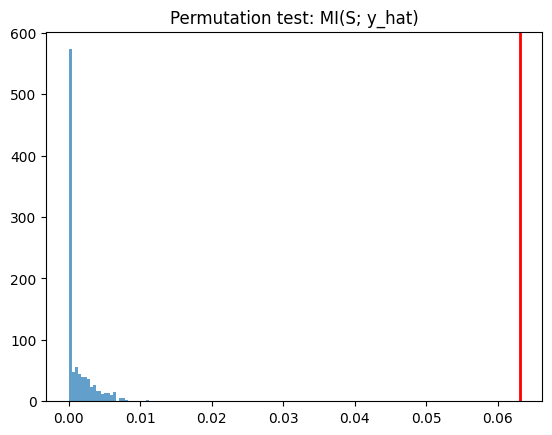

In [16]:
import matplotlib.pyplot as plt

plt.hist(mi_perm, bins=30, alpha=0.7)
plt.axvline(mi_obs, color="red", linewidth=2)
plt.title("Permutation test: MI(S; y_hat)")
plt.show()


# Bootstrapping

In [17]:
import numpy as np
import pandas as pd
from scipy.stats import entropy
from sklearn.feature_selection import mutual_info_classif

# --- config ---
n_boot = 500
rng = np.random.default_rng(42)

# --- prepare base data ---
work = df[["y_hat", "L"]].dropna().copy()
n = len(work)

def compute_nmi(sample_df, alpha):
    thr = sample_df["L"].quantile(1 - alpha)
    S = (sample_df["L"] >= thr).astype(int).to_numpy()
    Z = sample_df[["y_hat"]].to_numpy()

    # entropy H(S)
    p = np.array([S.mean(), 1 - S.mean()])
    H = entropy(p, base=np.e)
    if H == 0:
        return np.nan

    # MI
    I = mutual_info_classif(Z, S, discrete_features=False, random_state=42)[0]
    return I / H

# --- bootstrap ---
nmi_boot = np.empty(n_boot)

for i in range(n_boot):
    idx = rng.integers(0, n, size=n)      # sample with replacement
    sample = work.iloc[idx]
    nmi_boot[i] = compute_nmi(sample, alpha_star)

nmi_boot = nmi_boot[~np.isnan(nmi_boot)]


In [18]:
print(
    f"Bootstrap stability (NMI(S; y_hat))\n"
    f"----------------------------------\n"
    f"alpha*        : {alpha_star:.3f}\n"
    f"n_boot        : {len(nmi_boot)}\n"
    f"median NMI    : {np.median(nmi_boot):.3f}\n"
    f"mean NMI      : {np.mean(nmi_boot):.3f}\n"
    f"IQR           : {np.percentile(nmi_boot, 75) - np.percentile(nmi_boot, 25):.3f}\n"
    f"std           : {np.std(nmi_boot):.3f}\n"
    f"min / max     : {np.min(nmi_boot):.3f} / {np.max(nmi_boot):.3f}"
)


Bootstrap stability (NMI(S; y_hat))
----------------------------------
alpha*        : 0.030
n_boot        : 500
median NMI    : 0.567
mean NMI      : 0.567
IQR           : 0.056
std           : 0.044
min / max     : 0.441 / 0.686


# Next Steps

In [19]:
import numpy as np
from sklearn.linear_model import LogisticRegression

FEATURE = "Z_load"

X = df[["y_hat"]].to_numpy()
S = (df["L"] >= df["L"].quantile(1 - alpha_star)).astype(int).to_numpy()

clf = LogisticRegression(solver="lbfgs")
clf.fit(X, S)

p_hat = clf.predict_proba(X)[:, 1]


In [20]:
S_res = S - p_hat

In [21]:
from sklearn.feature_selection import mutual_info_regression

hour = (
    df[FEATURE]
).to_numpy()

mi_hour = mutual_info_regression(
    hour.reshape(-1, 1),
    S_res,
    random_state=42
)[0]


In [22]:
rng = np.random.default_rng(42)
mi_perm = []

for _ in range(500):
    mi_perm.append(
        mutual_info_regression(
            rng.permutation(hour).reshape(-1, 1),
            S_res,
            random_state=42
        )[0]
    )

p_perm = (np.sum(np.array(mi_perm) >= mi_hour) + 1) / (len(mi_perm) + 1)

print(f"MI({FEATURE}; S | y_hat) = {mi_hour:.4f}, p = {p_perm:.4g}")


MI(Z_load; S | y_hat) = 0.2895, p = 0.001996
